# 开篇

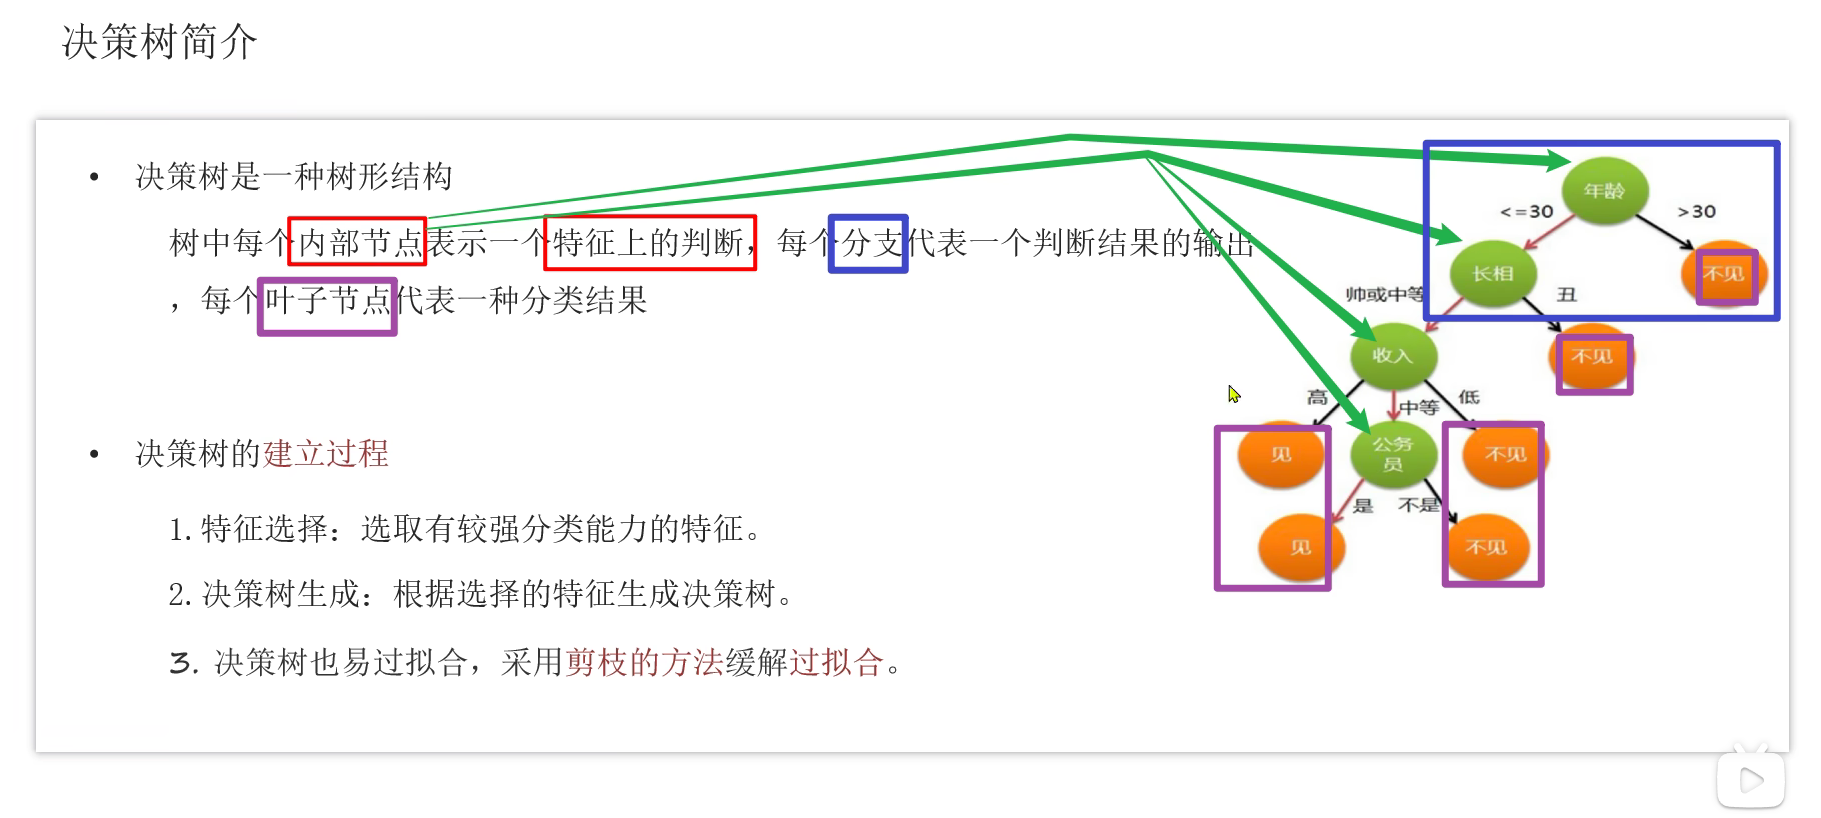

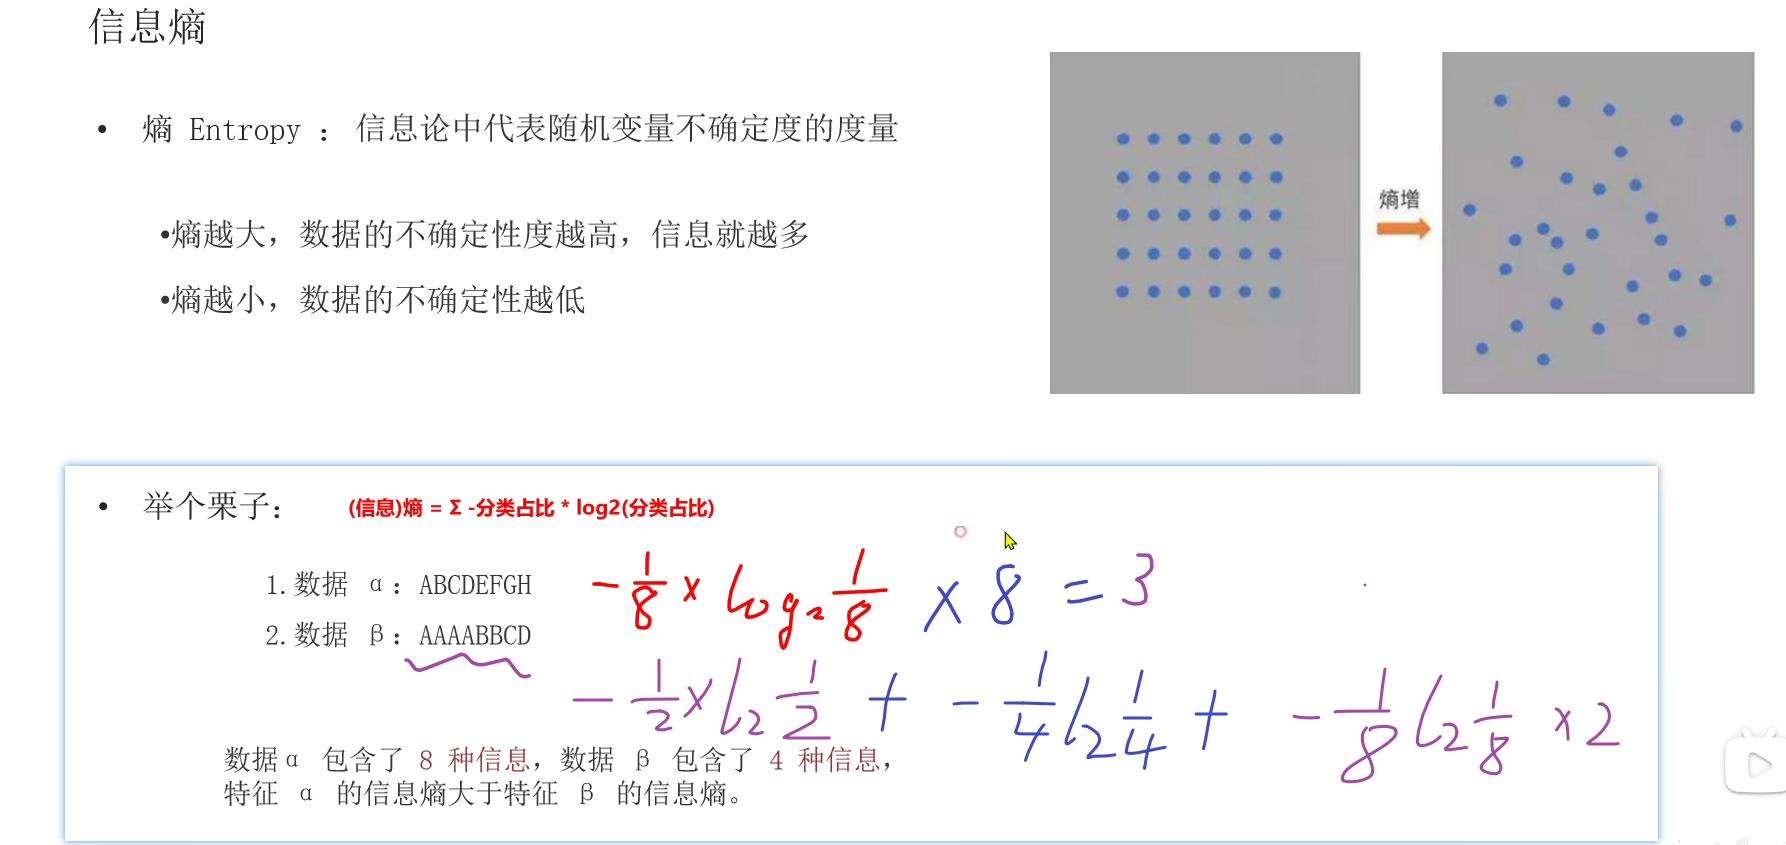

* 熵就是代表数据的混乱程度 不确定性越大信息熵越高 不确定性越小 信息熵越小
* 假如一个箱子里红球：100 绿球：0 蓝球：0  他的信息熵就是0

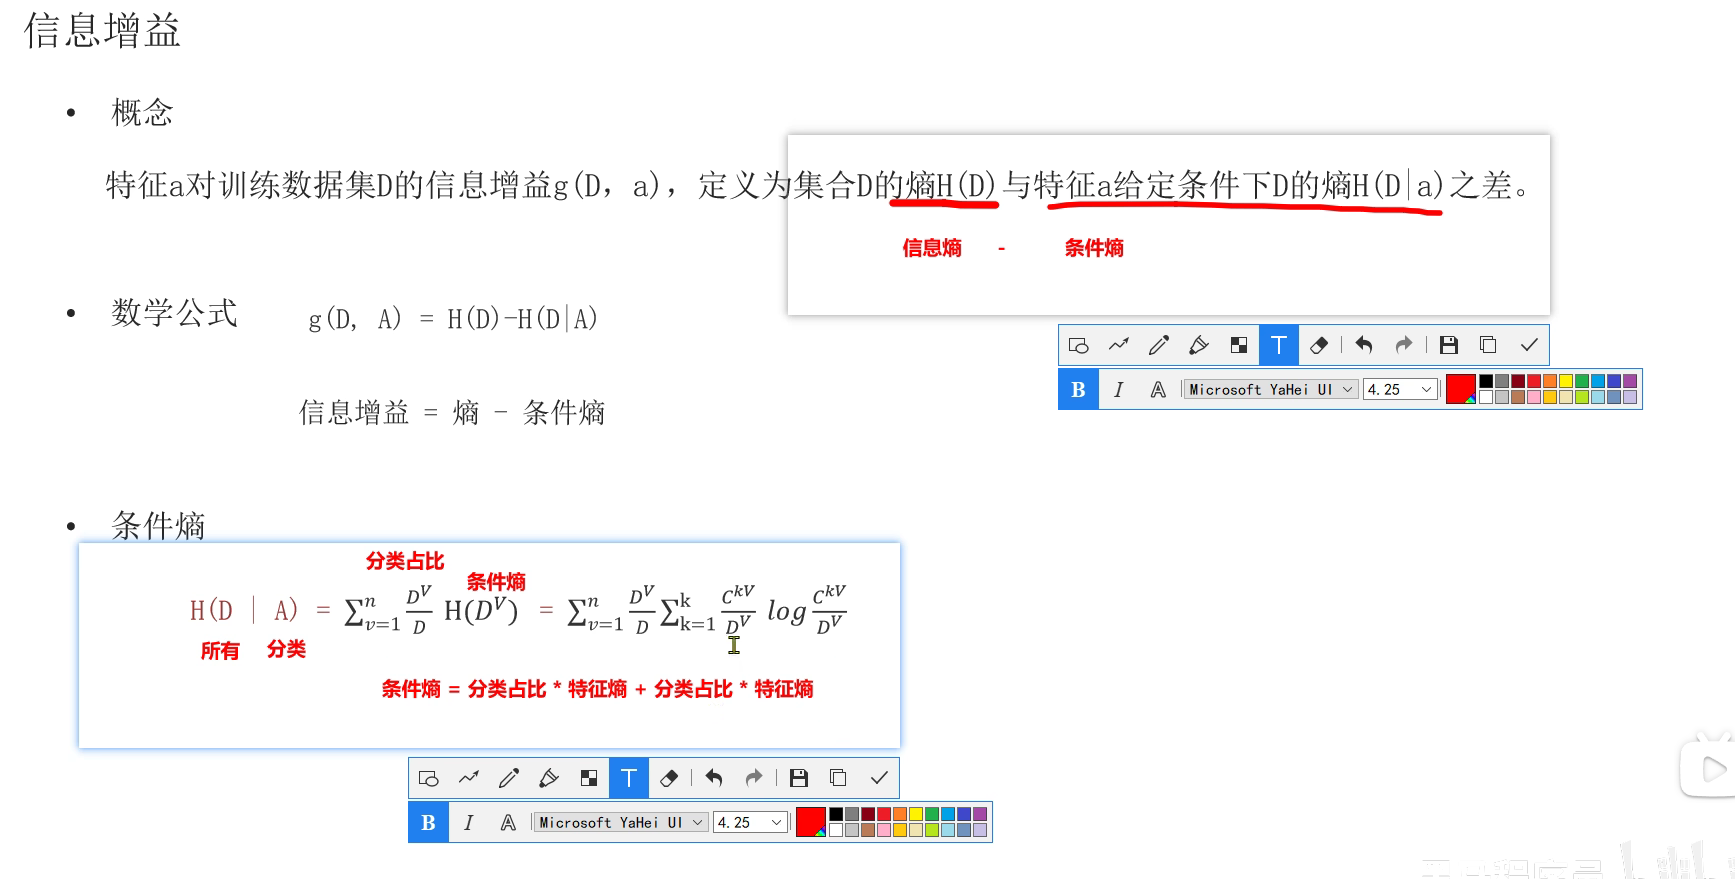

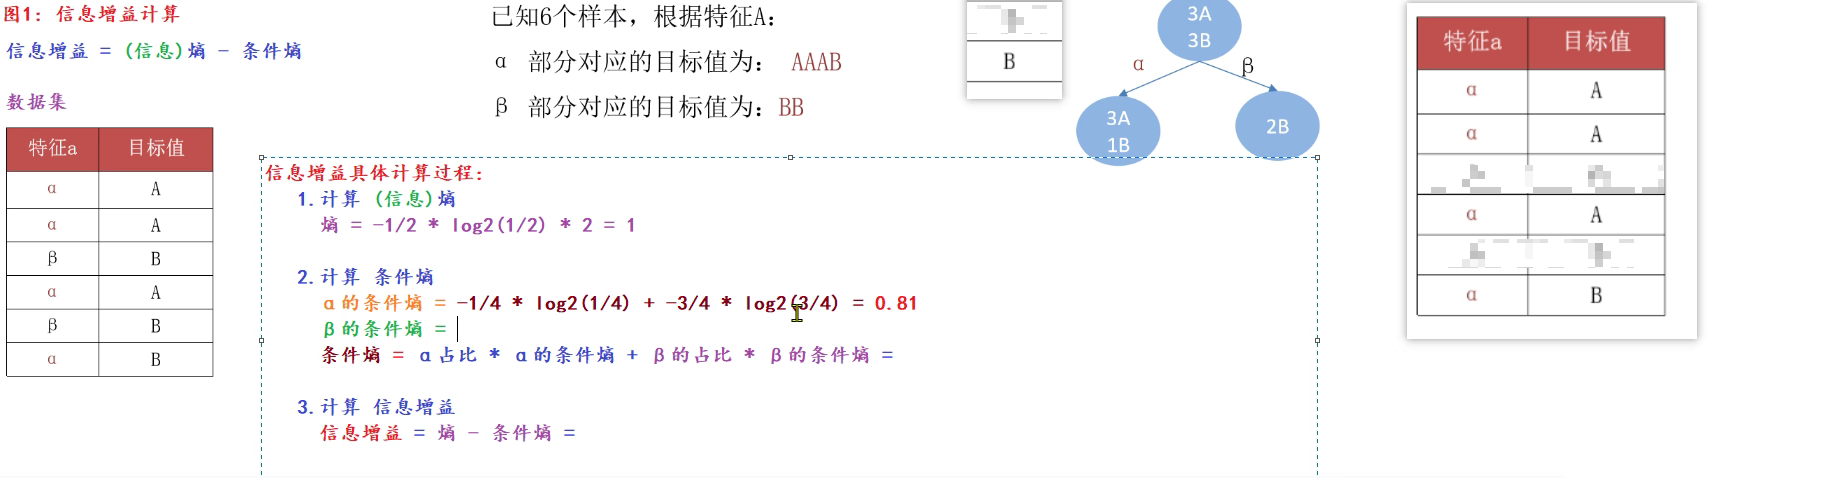

条件熵与信息熵
* 条件熵其实和信息熵差别不大
* 信息熵只看目标值整体分布，不考虑任何特征，根据AB的目标值进行计算
* 条件熵是 限定特征值之后 根据目标值AB进行计算
* 总结就是 信息熵是看数据整体多乱 条件熵就是知道某个特征之后多乱
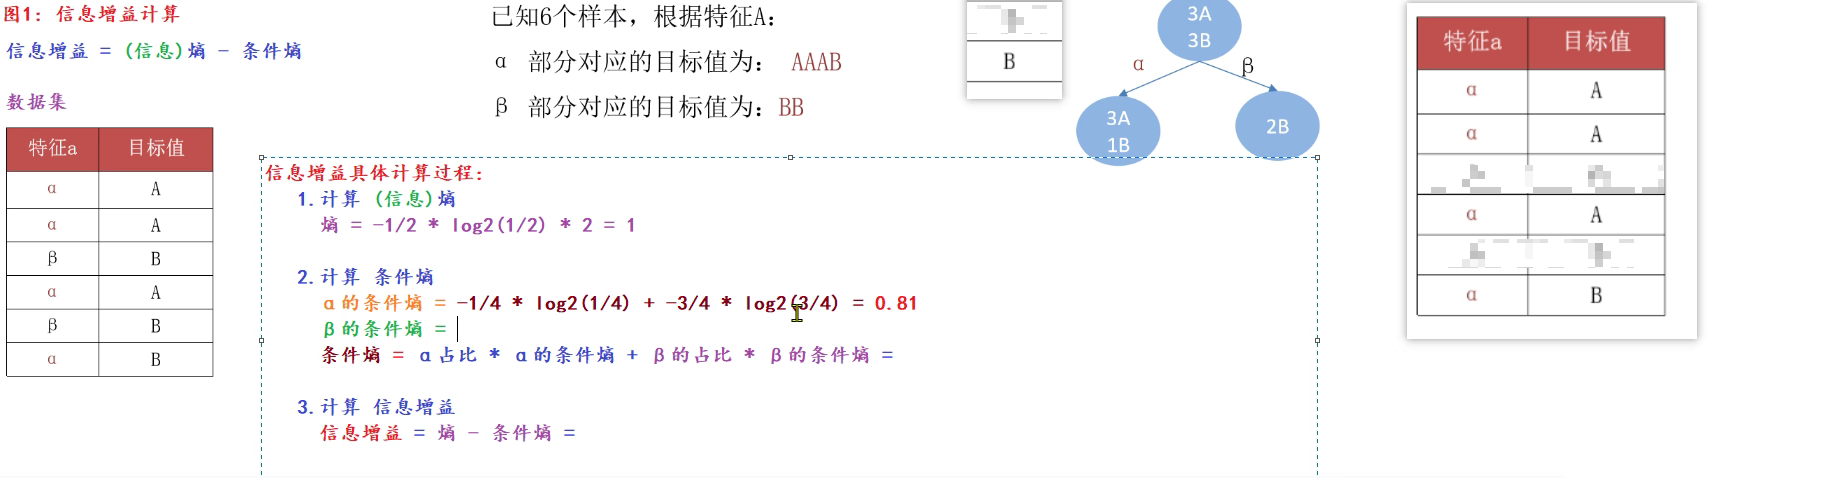

信息增益
* 信息增益= 信息熵-条件熵
* 信息增益的结果越大 该条件熵越小 条件熵越小 说明该特征越不混乱 越重要

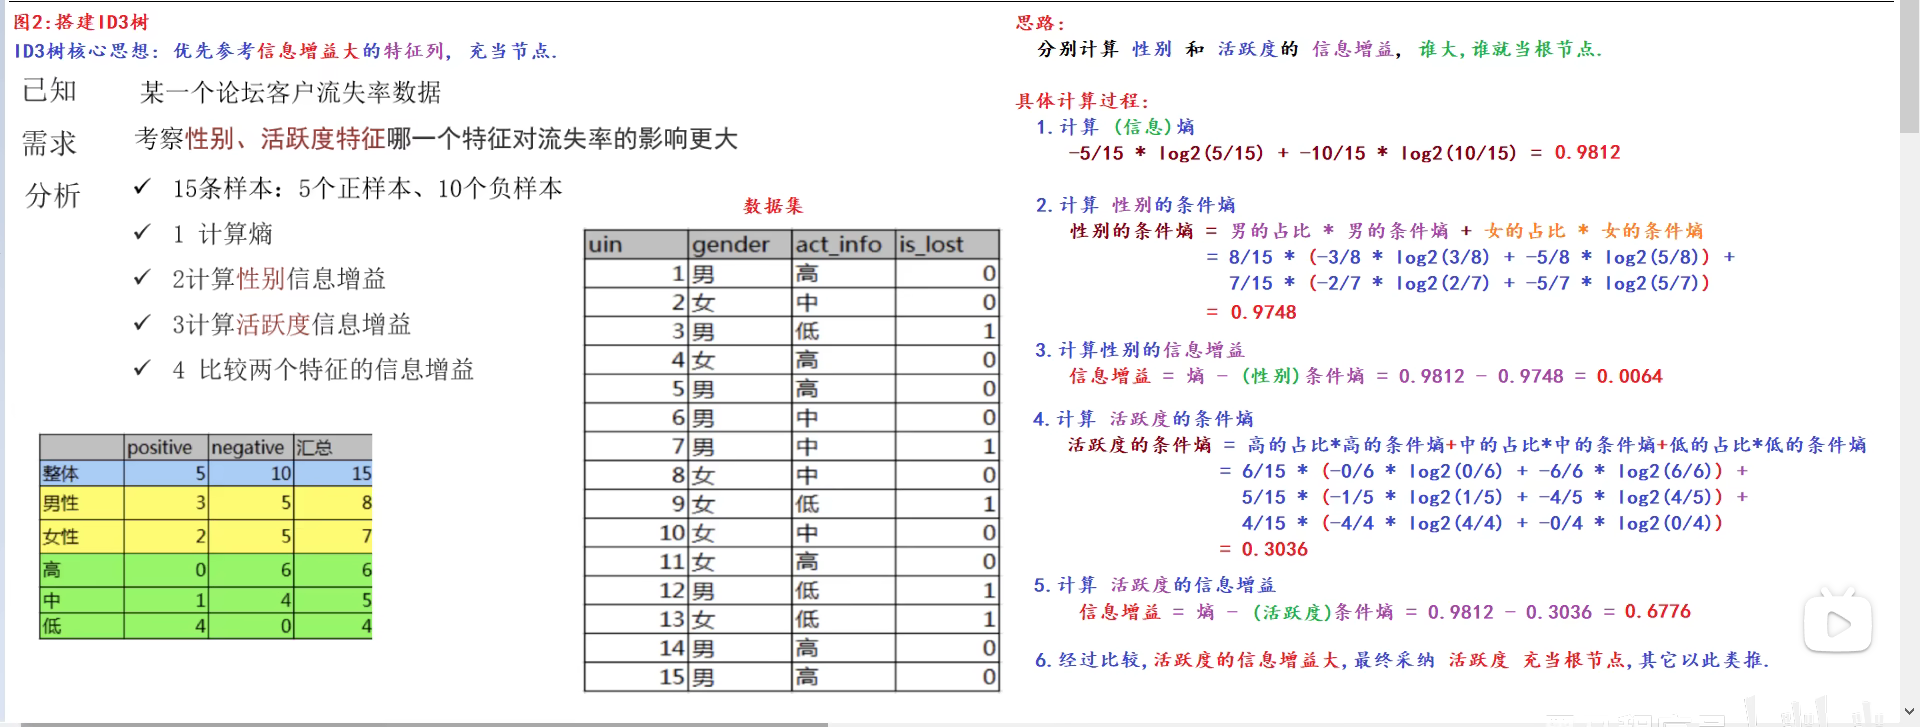

男的条件熵是 分母是男生总数 分子是特征是男生的前提下流失数或没有流失数

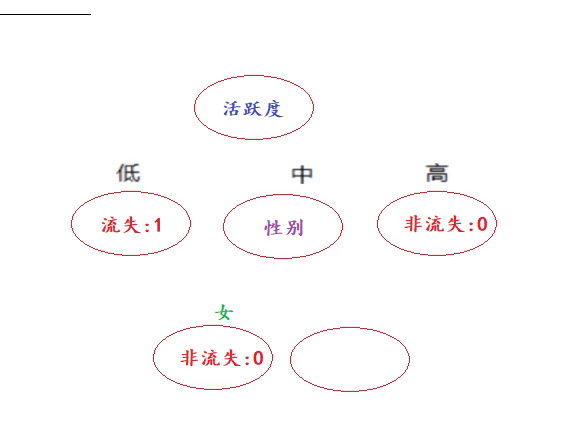

根据信息增益大的弄完 再根据信息增益小的（性别）排

* 上述是ID3决策树，它的缺点是当分类过于多的时候，信息增益会产生假大
* 例如 学生信息表中有学号这一特征，用来判断他期末是否能及格
* 因为学号唯一 假设学号为2026，他及格了，所以条件熵为0 分母为1 分子为0或者1 无论零或1 条件熵都为0
* 这会导致学号的信息增益为最大 可是实际上 期末考试是否及格与学号一毛钱关系没有

因为ID3的缺点 c4.5决策数应运而生

信息增益率=信息增益/特征熵
* 特征熵举例：‘学号’特征下总共有60个分类 其中一个分类占a=1/60(学号唯一所以一个人一个) 特征熵=-aloga

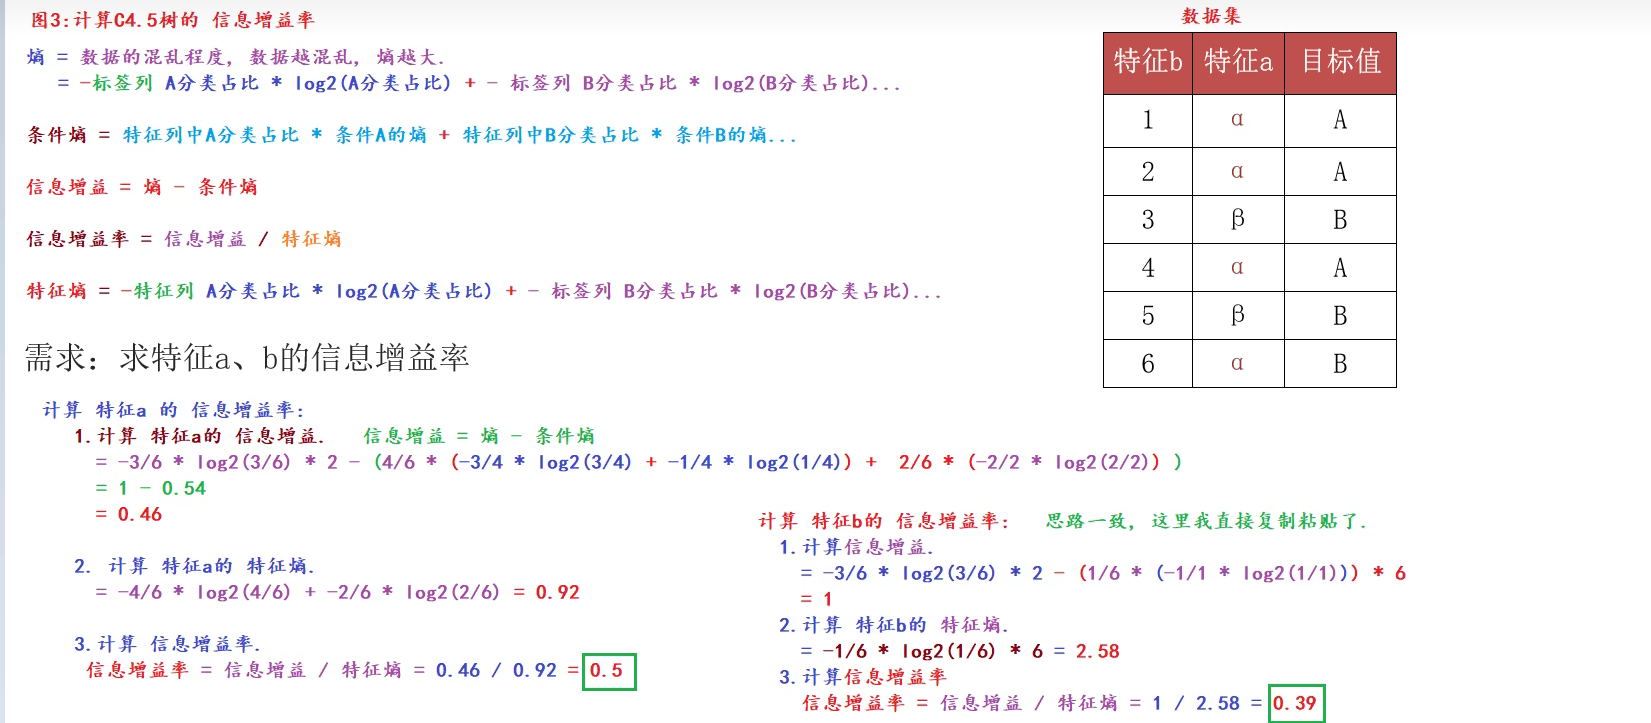

# CART决策树

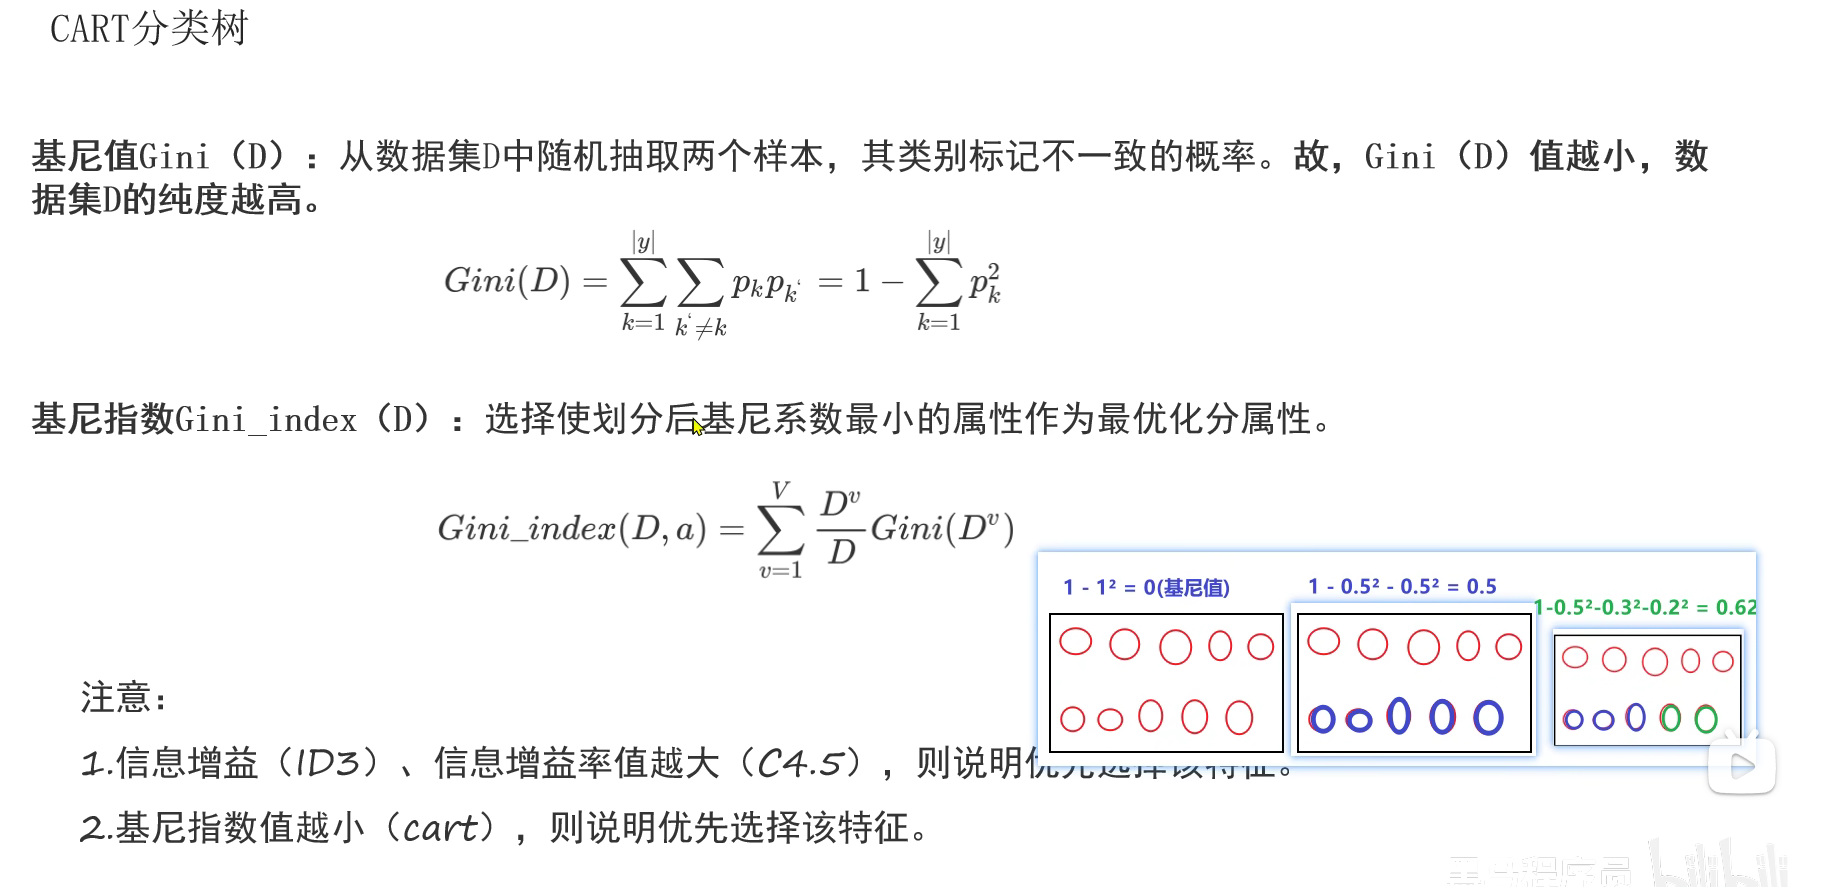

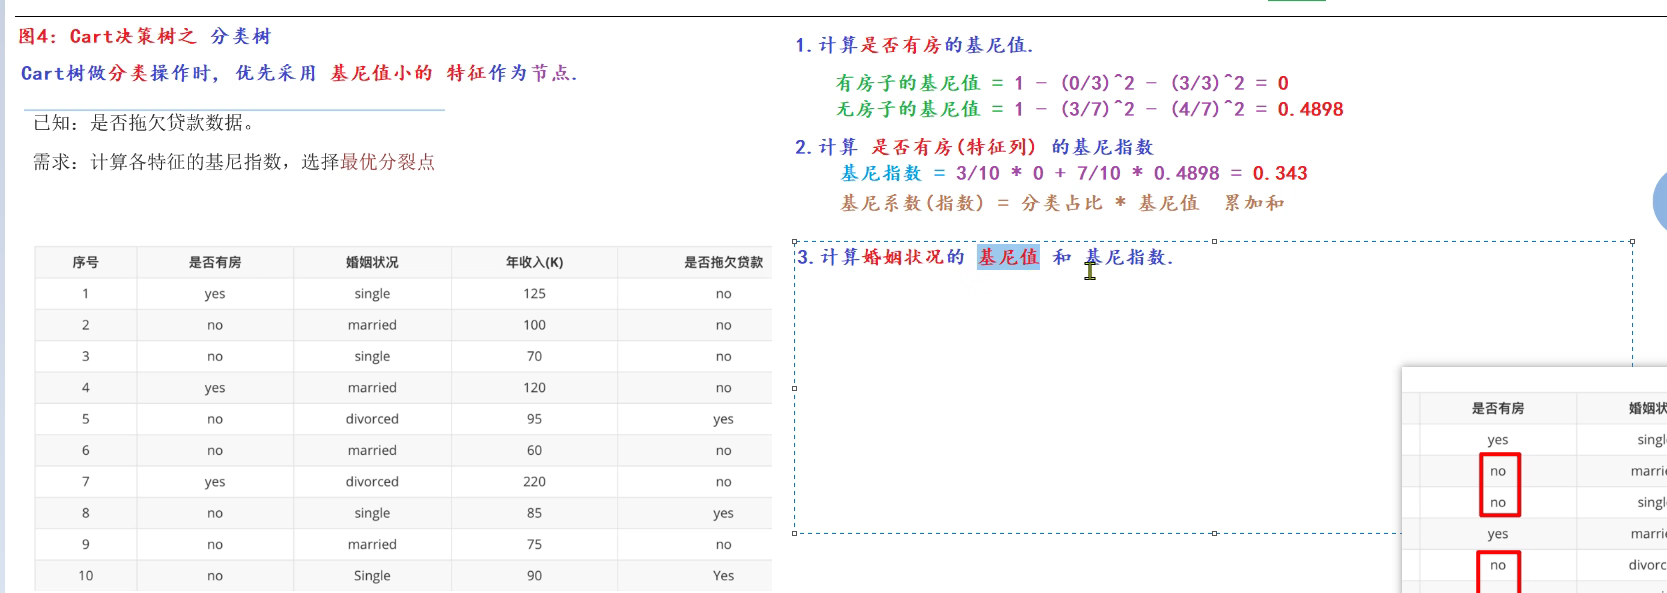

 * 基尼值计算方法：有房子共有3个 0个拖欠 0/3 3个不拖欠 3/3 用1减去他们的平方就是有房子的基尼值 无房子同理
* 基尼指数计算方法：有房子占样本总数的3/10*有房子基尼值 +无房子占样本总数7/10\*有房子基尼值
* 选基尼指数小的作为根节点

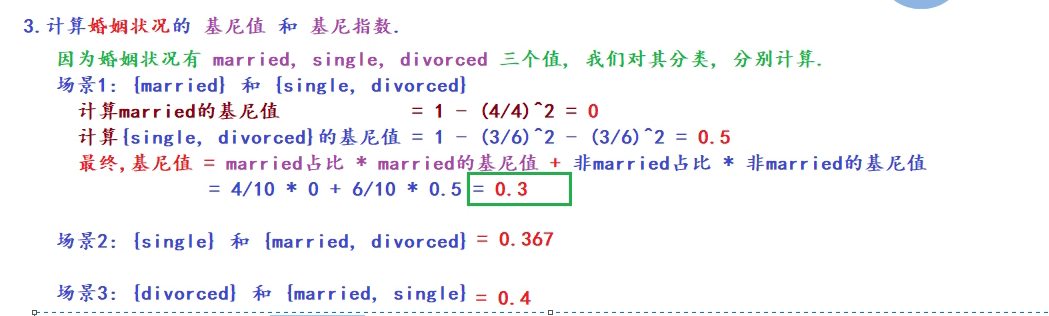

* cart树 因为是二叉树 所以要分两个叉,所以需要把 m s d 分组三种情况 看谁单独在一个叉 剩下两个在其他

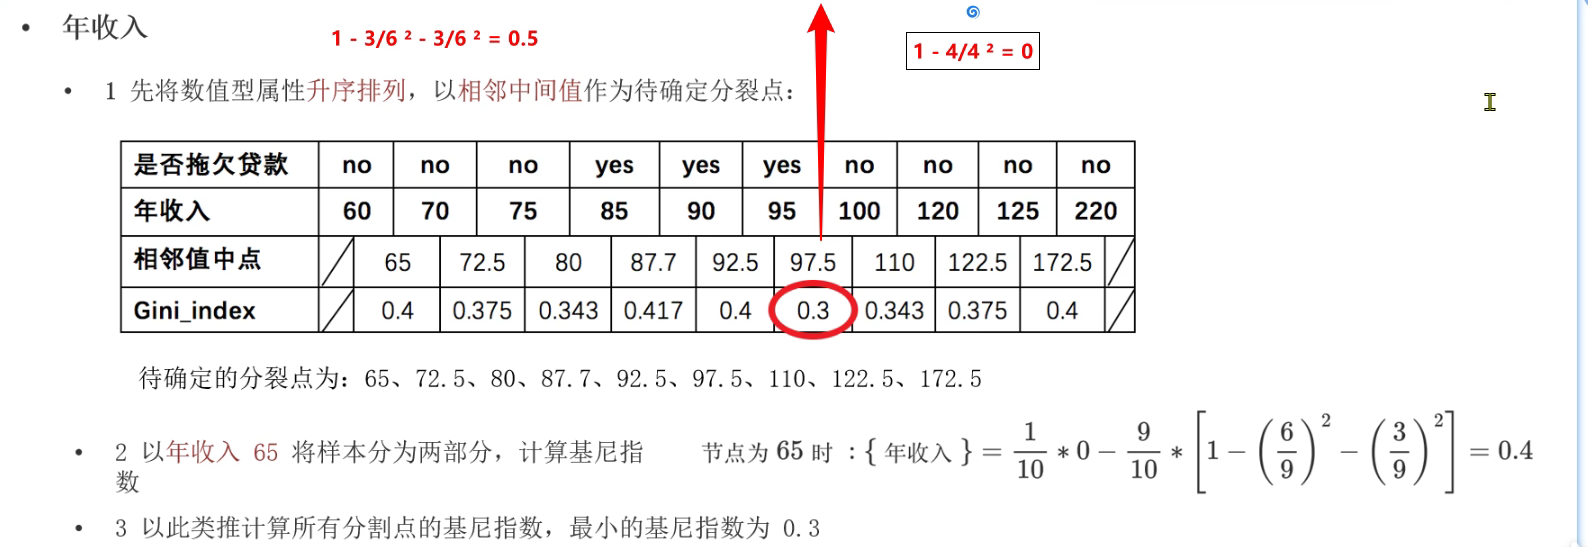

* 年收入基尼值计算：先取相邻两个数的平均数 算9次 第一次 小于等于65和其他（其他有9个 其他就是大于65的） 第二次 小于72.5和其他

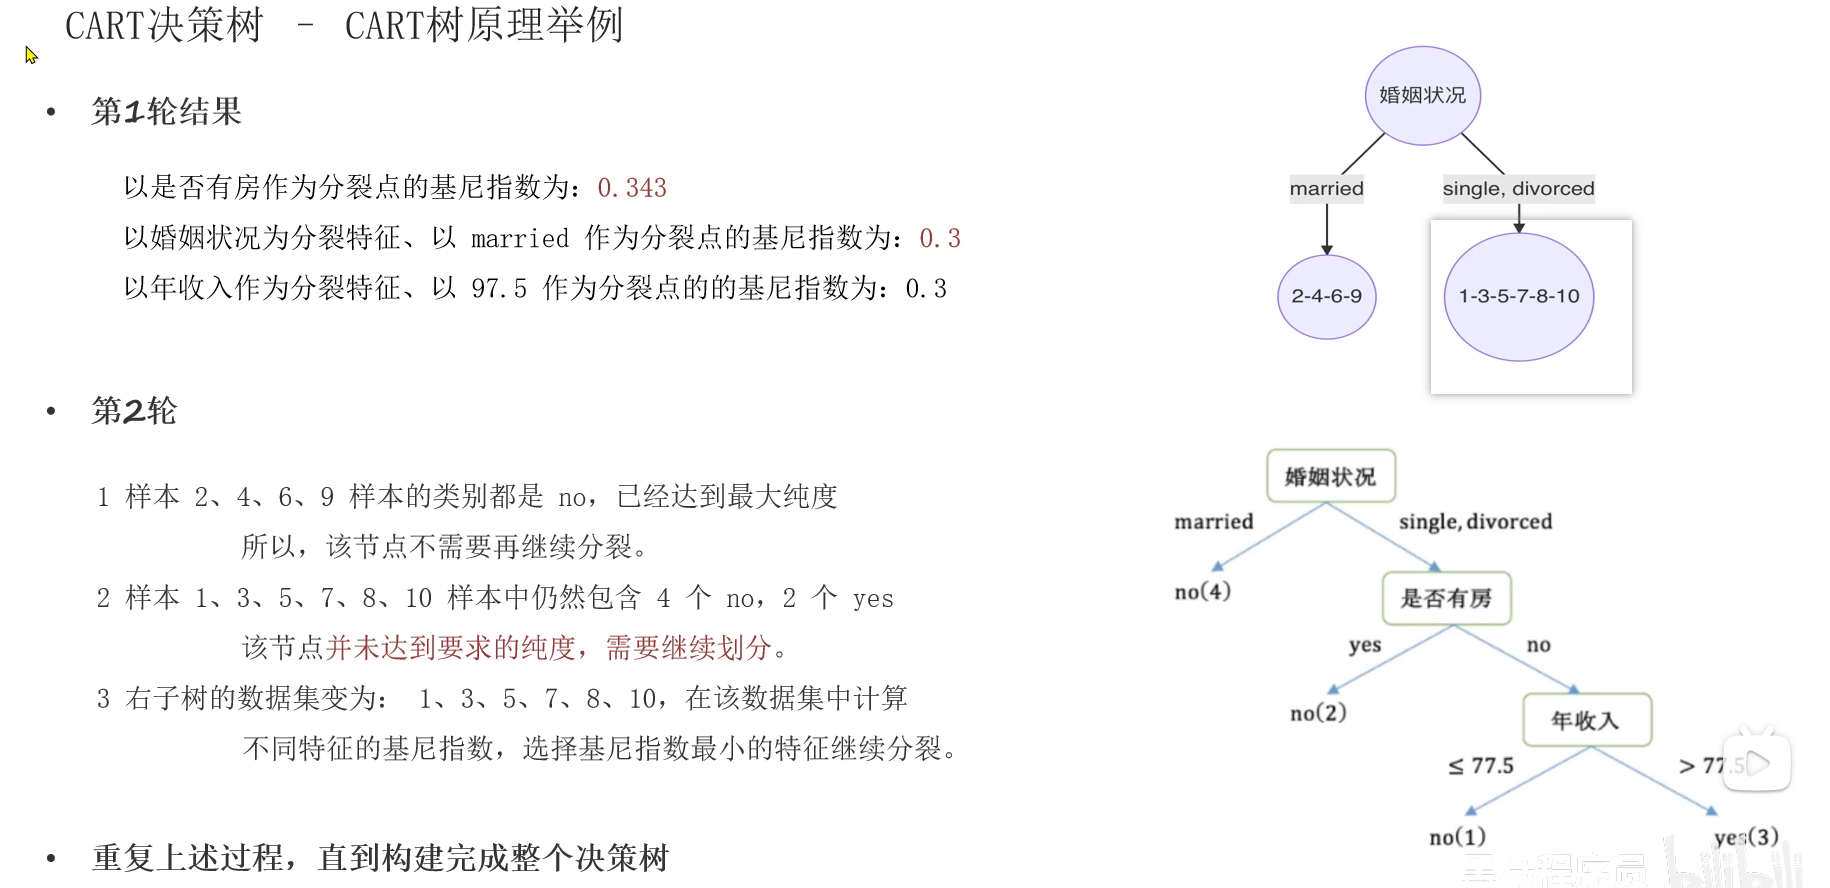

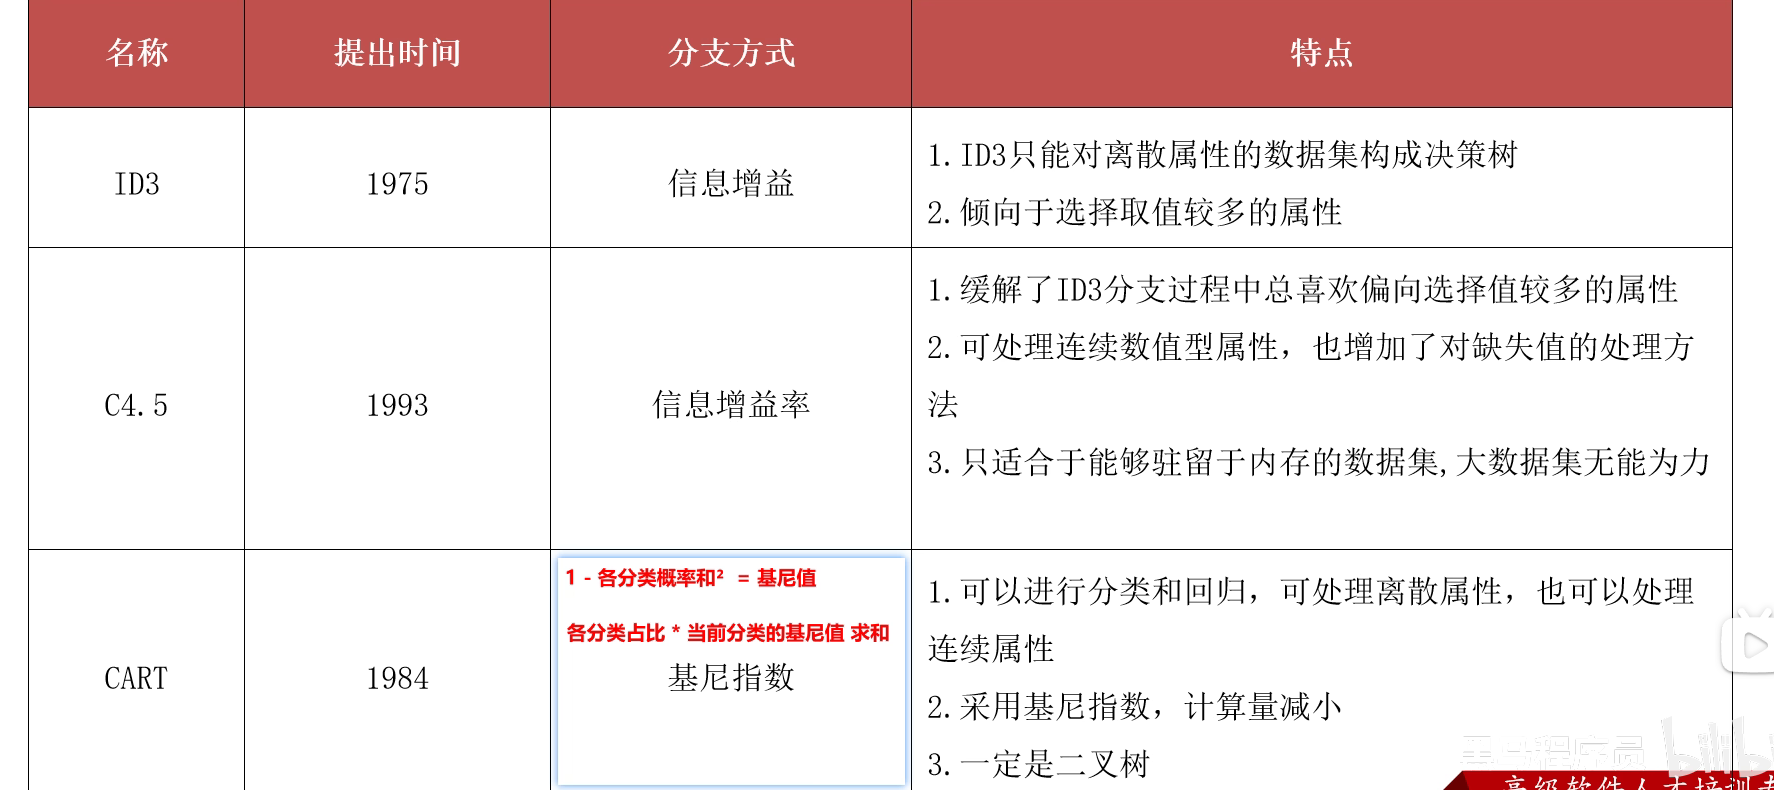

## 决策分类树案例_泰坦尼克号

In [ ]:
"""
案例: 演示 CART 分类回归决策树的 分类功能.
"""

# 导包
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


# 1. 加载数据.
data = pd.read_csv('./data/train.csv')
# data.info()

# 2. 数据的预处理.
# 2.1 提取特征和标签.
x = data[['Pclass', 'Sex', 'Age']]
y = data['Survived']
# print(x.head(5))
# print(y.head(5))

# 2.2 发现Age列有确实, 我们用该列的 平均值做填充.
# x['Age'].fillna(x['Age'].mean(), inplace=True)      # 会报警告, 但是可以用.
# x['Age'] = x['Age'].fillna(x['Age'].mean())           # 会报警告, 因为是直接修改源数据的.

# 解决方案, copy()数据之后再改.
x = x.copy()                                          # 拷贝数据, 不写也行.
x['Age'] = x['Age'].fillna(x['Age'].mean())           # 会报警告, 因为是直接修改源数据的.

# 2.3 查看处理后的数据集.
# x.info()

# 2.4 针对于 Sex列, 进行one-hot编码.
x = pd.get_dummies(x, columns=['Sex'])
# x.info()

# 2.5 划分训练集和测试集.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=23)

# 3. 特征工程.

# 4. 模型训练
# 参数: max_depth=10 意思是: 绘制的 决策树结构, 最多10层.
estimator = DecisionTreeClassifier(max_depth=10)
estimator.fit(x_train, y_train)

# 5. 模型预测.
y_pred = estimator.predict(x_test)
print(f'预测值为: {y_pred}')

# 6. 模型评估.
print(f'分类评估报告: \n {classification_report(y_test, y_pred)}')

# 7. 绘制 决策树 图.
plt.figure(figsize=(300, 200))    # 设置图片大小, 30 * 100(dpi) * 20 * 100(dpi) = 3000 * 2000像素
# 参1: 模型对象, 参2: 是否用颜色填充, 参3: 绘制的 决策树结构, 最多10层.
plot_tree(estimator, filled=True, max_depth=10)
plt.savefig('./data/my_titanic.png')
plt.show()

## 回归树
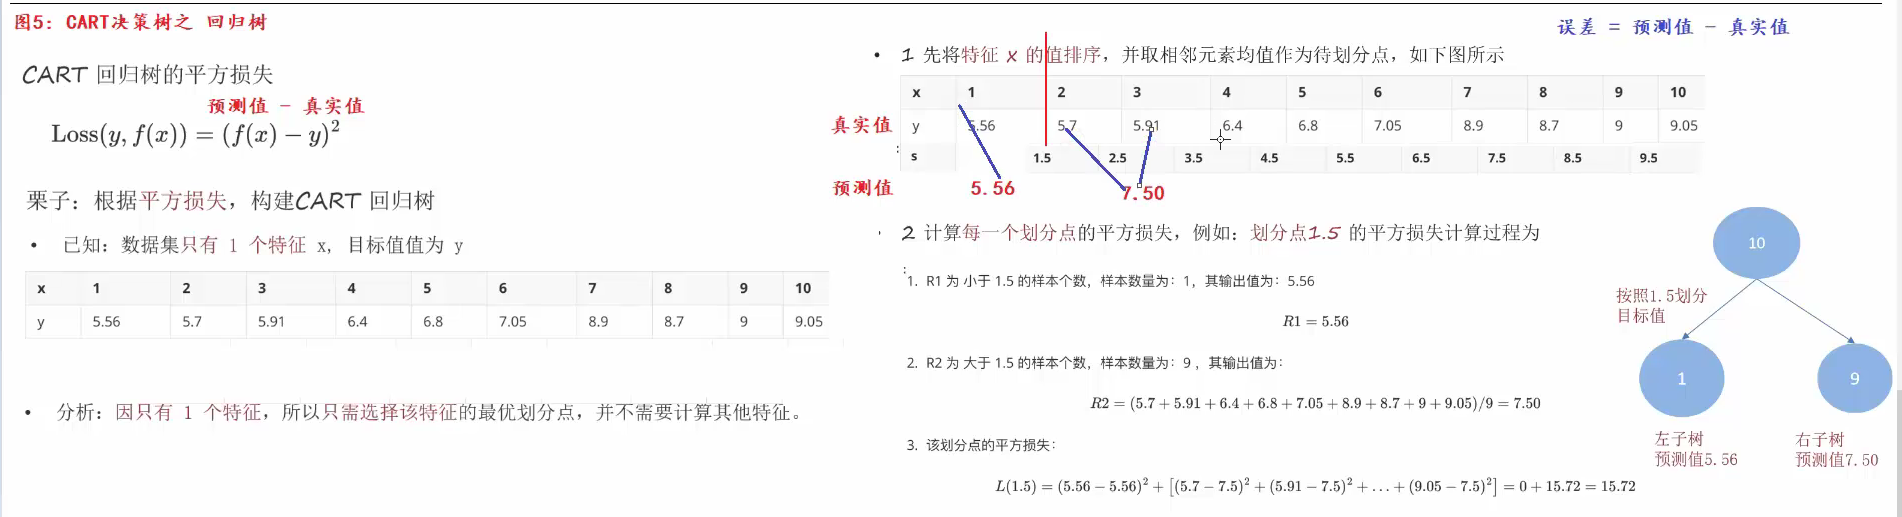

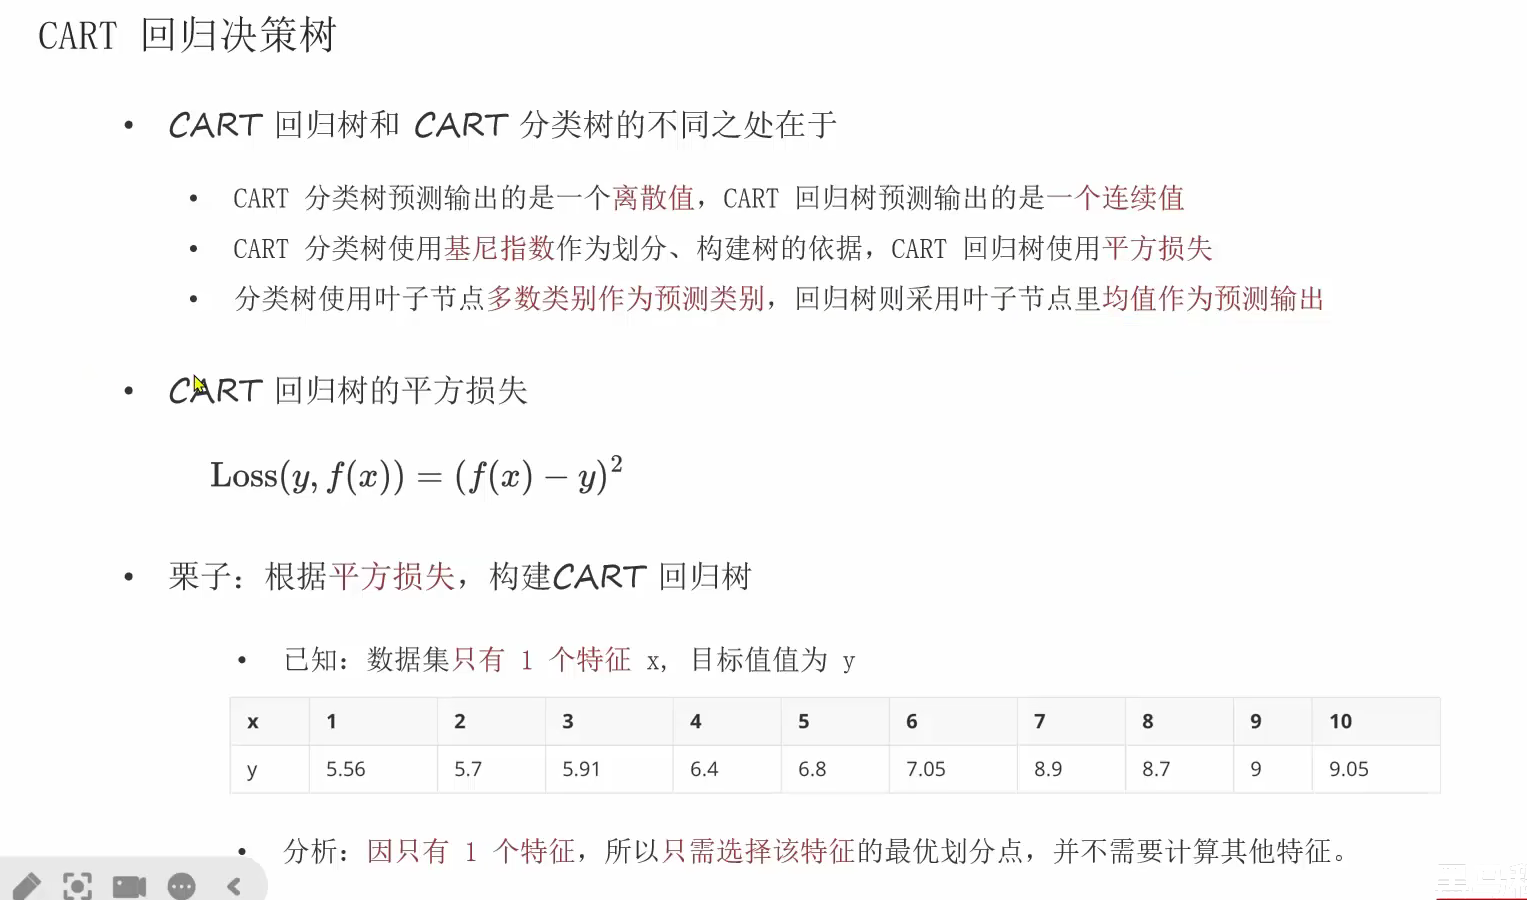

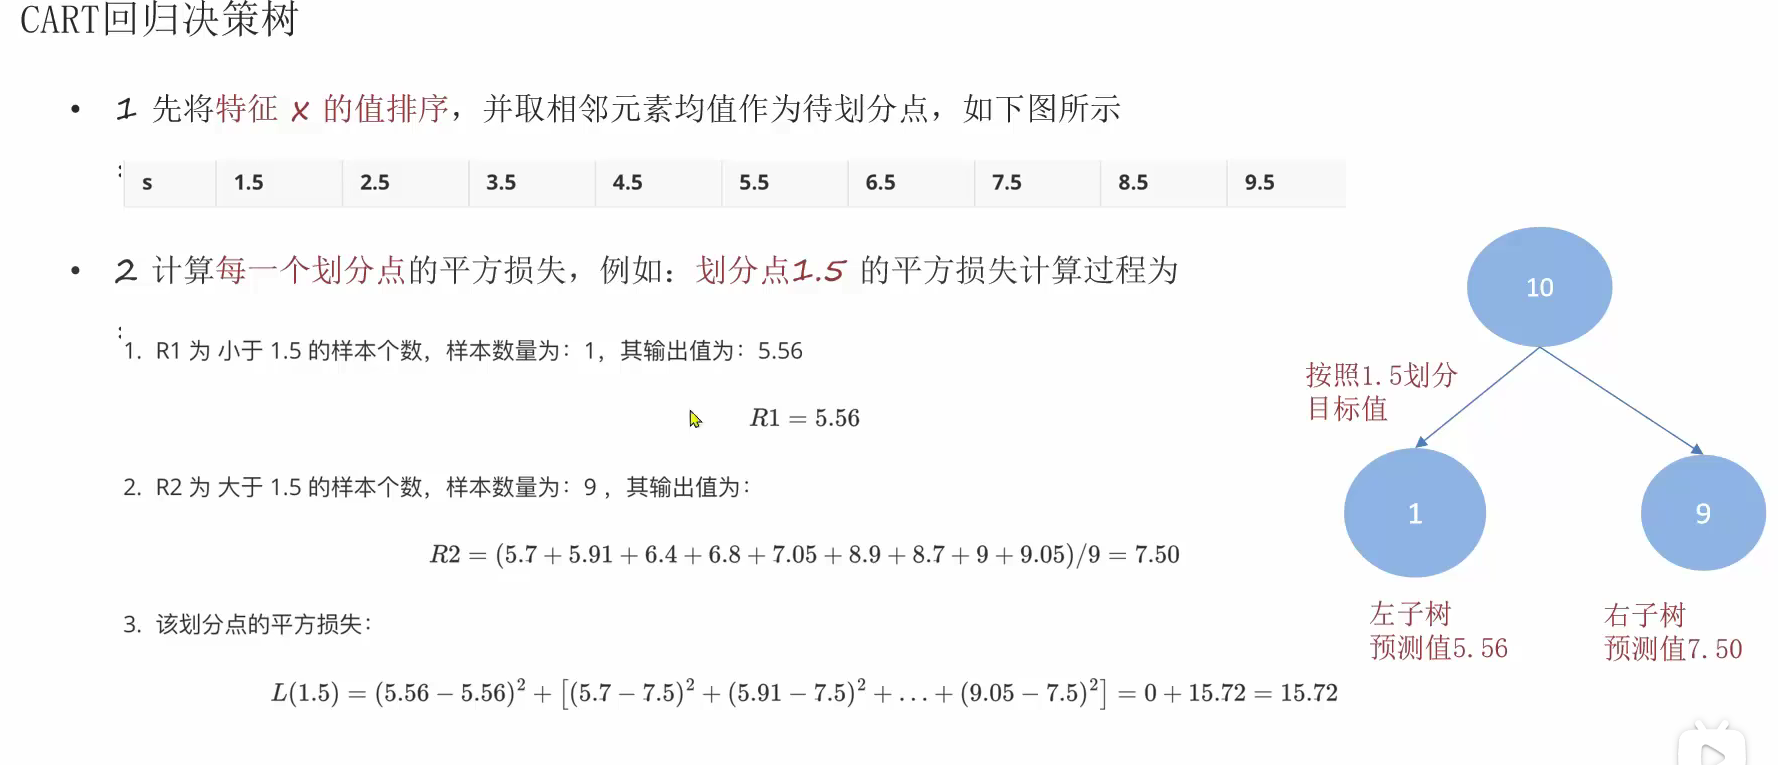

* 算9次，先算x的均值 根据x的值对y分组
* 第一组是小于1.5和其他 第二组是小于2.5和其他 ......
* 每组两部分 左侧和右侧的y都要求平均值 作为预测值 用预测值-真实值的平方和 加起来就是平方损失

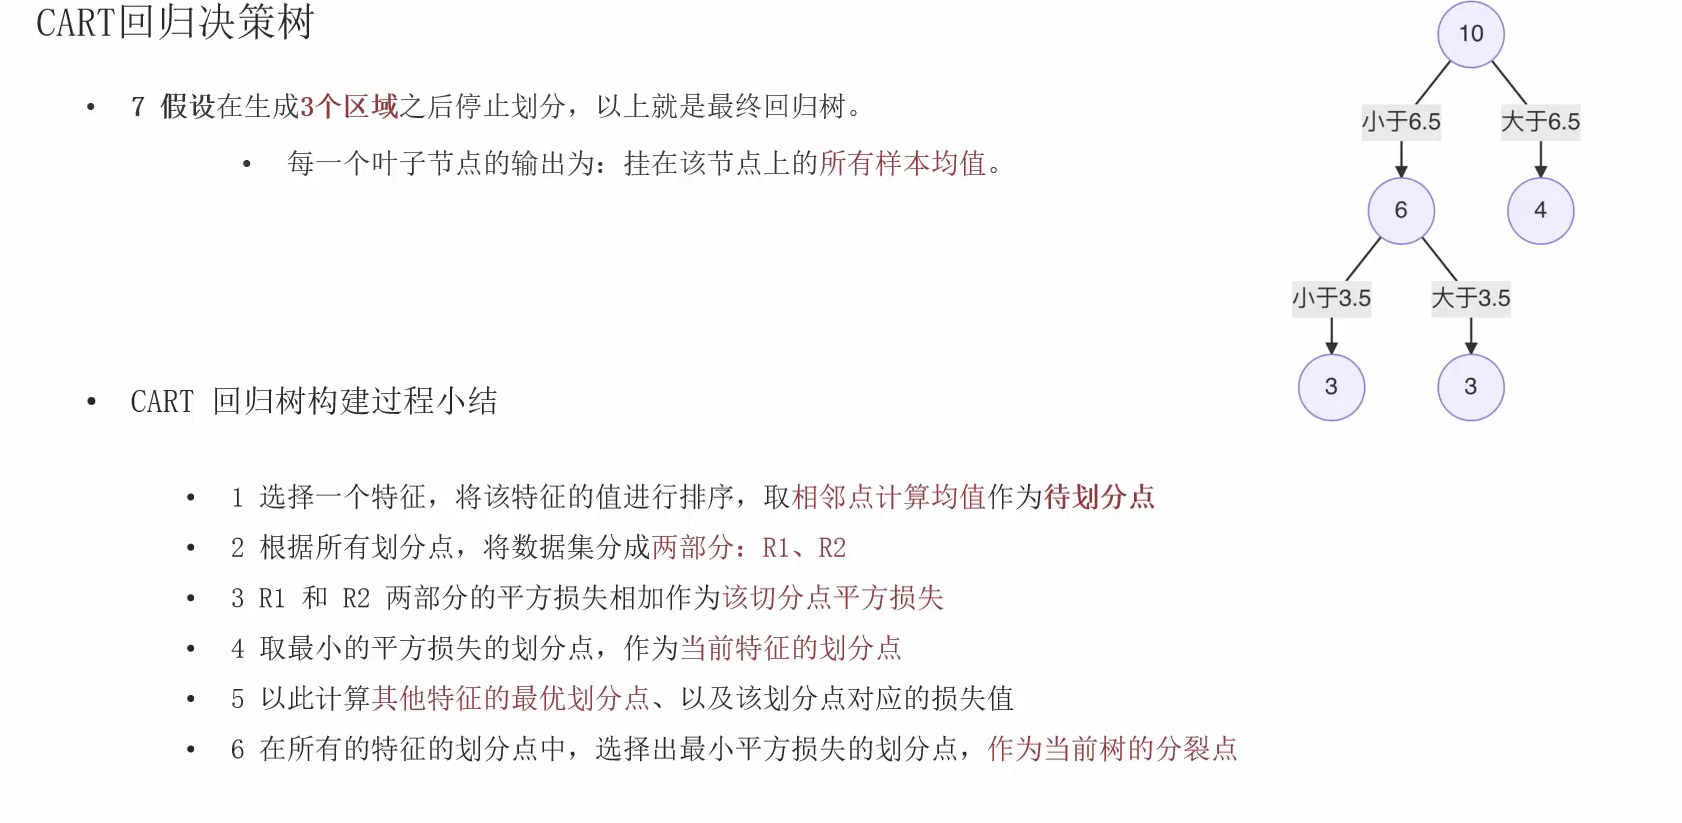

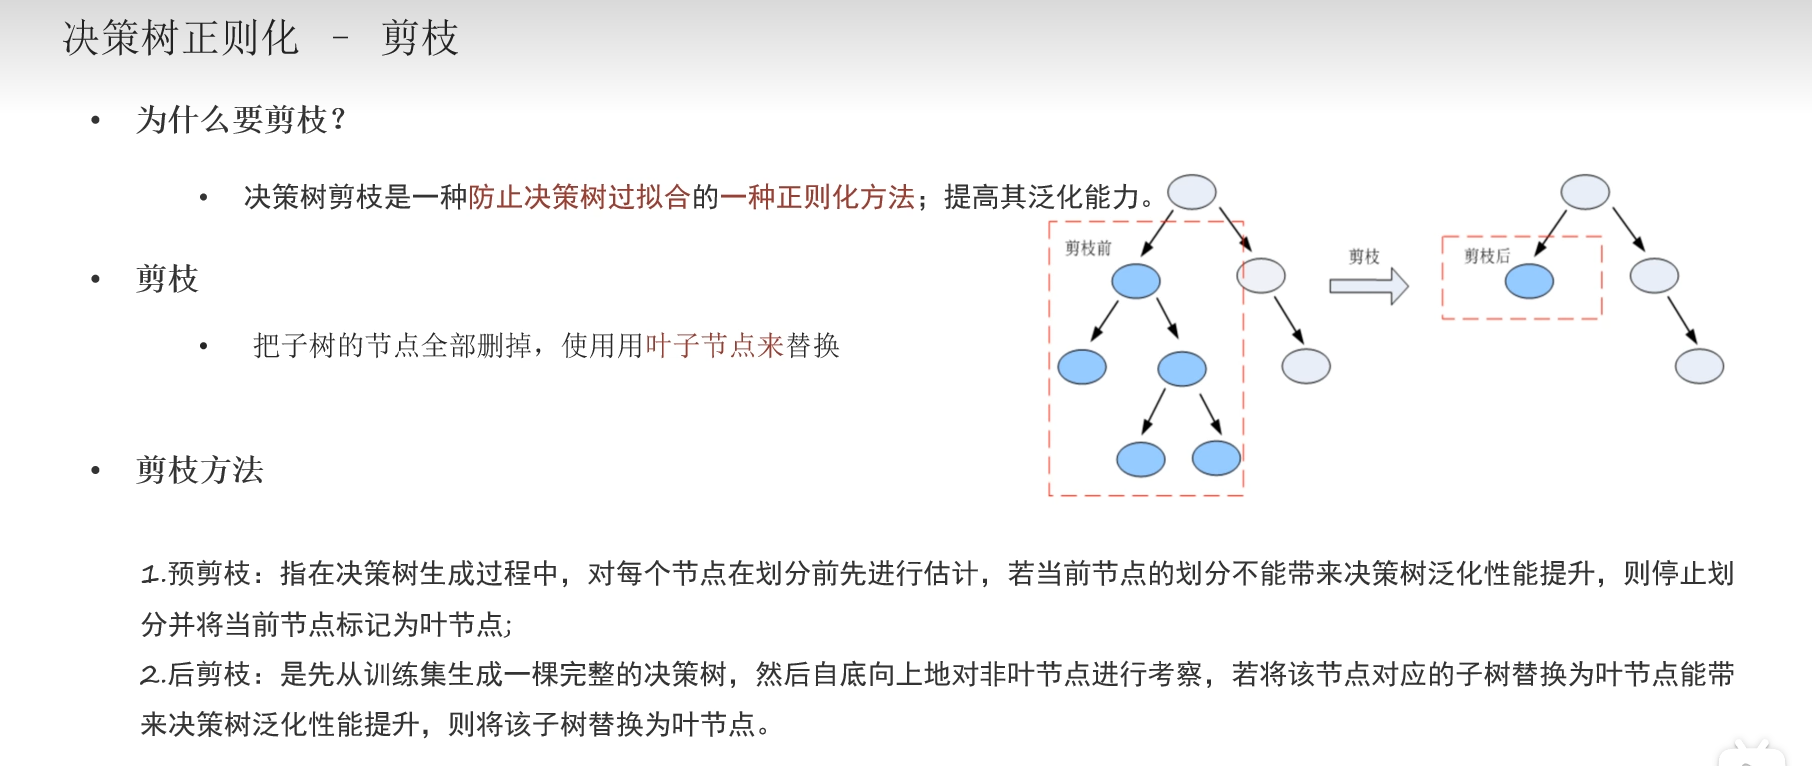

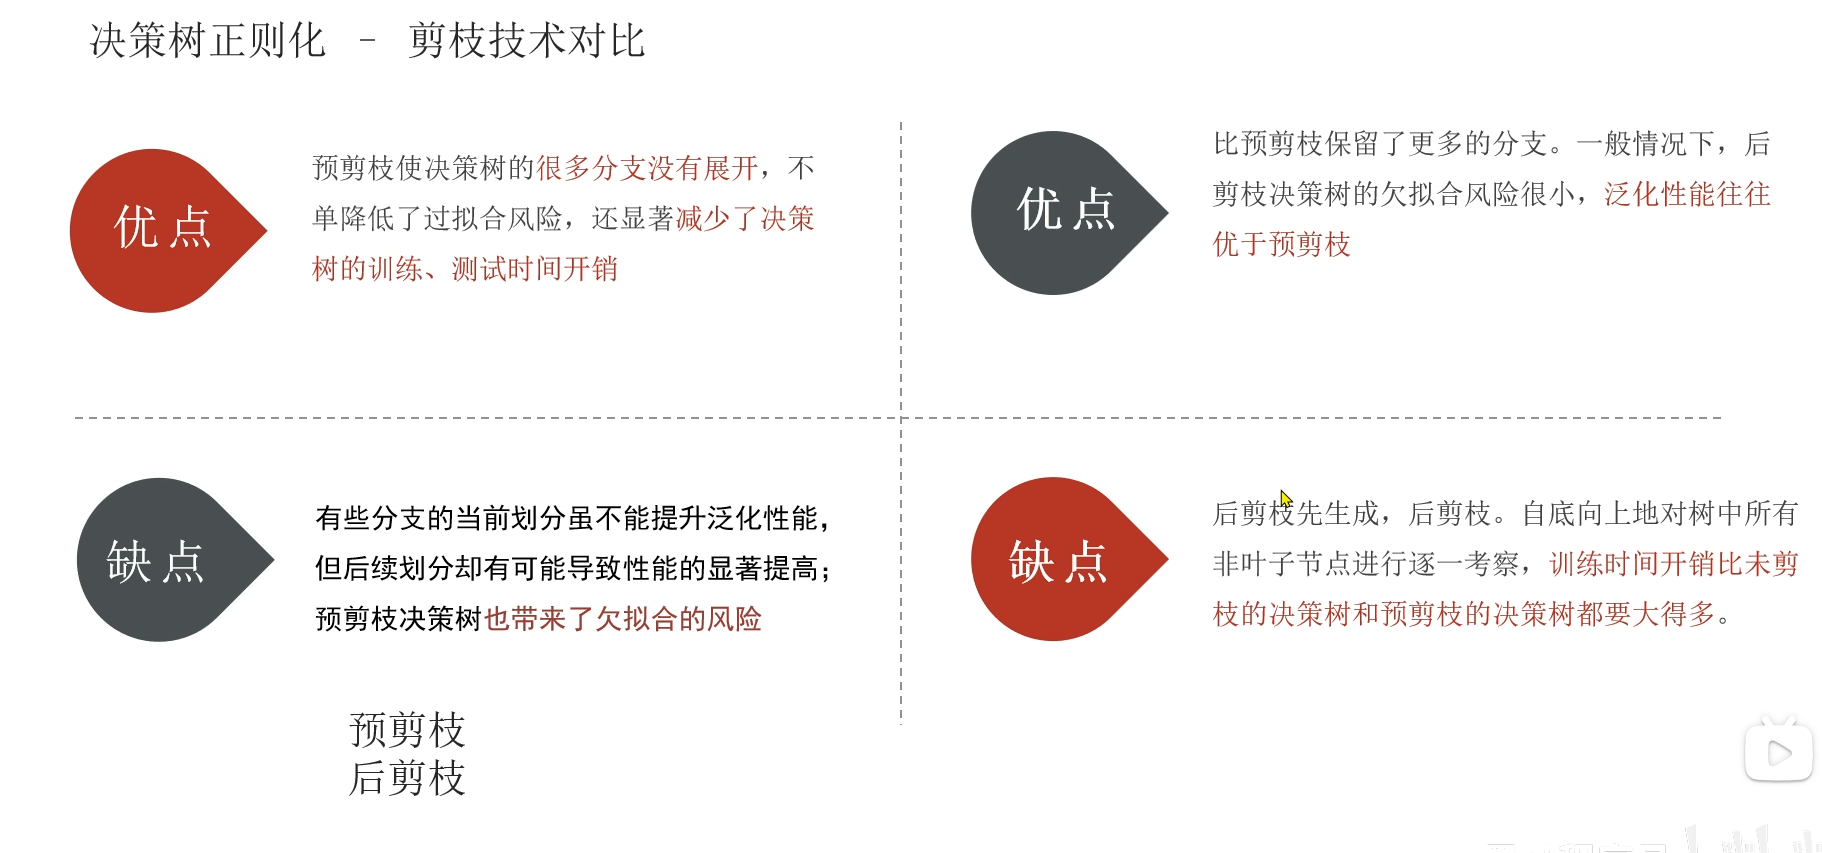